# Day 14: Training Pipeline Best Practices

> **Goal:** Refactor messy training code into clean, reusable functions. Add checkpointing, reproducibility, and logging.

---

## Why Clean Code Matters

So far we've copy-pasted training loops. Today we'll create a **reusable pipeline** that:
1. Has clean `train_one_epoch()` and `evaluate()` functions
2. Saves and loads model checkpoints
3. Is reproducible (same seed → same results)
4. Logs metrics and plots them automatically

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import os
import json
import time
from pathlib import Path

---
## 1. Reproducibility

Set all random seeds so experiments are repeatable.

In [6]:
import random
import numpy as np

def set_seed(seed=42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For fully deterministic behavior (may slow down training):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

Device: mps


---
## 2. Data Setup (Modular)

In [7]:
def get_mnist_loaders(batch_size=128, val_ratio=0.2, data_dir="./data"):
    """Create train, val, and test DataLoaders for MNIST."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])

    full_train = torchvision.datasets.MNIST(root=data_dir, train=True, download=True, transform=transform)
    test_data = torchvision.datasets.MNIST(root=data_dir, train=False, download=True, transform=transform)

    train_size = int((1 - val_ratio) * len(full_train))
    val_size = len(full_train) - train_size
    train_data, val_data = random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_mnist_loaders()
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 375, Val batches: 94, Test batches: 79


---
## 3. Model Definition

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=[256, 128], num_classes=10, dropout=0.2):
        super().__init__()
        layers: list[nn.Module] = [nn.Flatten()]
        prev_dim = input_dim
        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MLP().to(device)
print(model)
print(f"\nParameters: {sum(p.numel() for p in model.parameters()):,}")

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parameters: 235,914


---
## 4. Clean Training & Evaluation Functions

In [12]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    """Train for one epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    """Evaluate model. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

---
## 5. Checkpointing — Save & Load Models

**Why checkpoint?**
- Resume training after interruption
- Save the best model (based on val performance)
- Deploy later

In [9]:
def save_checkpoint(model, optimizer, epoch, val_loss, path):
    """Save model and optimizer state."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": val_loss,
    }, path)


def load_checkpoint(model, optimizer, path, device):
    """Load model and optimizer state. Returns the epoch."""
    checkpoint = torch.load(path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    return checkpoint["epoch"], checkpoint["val_loss"]

---
## 6. The Complete Training Pipeline

In [13]:
def train(model, train_loader, val_loader, epochs=10, lr=1e-3,
          device="cpu", checkpoint_dir="./checkpoints", patience=5):
    """Complete training pipeline with logging, checkpointing, and early stopping."""

    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_loss = float("inf")
    epochs_no_improve = 0

    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>10} | {'Time':>5}")
    print("-" * 75)

    for epoch in range(epochs):
        start = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn, device)
        lr_now = optimizer.param_groups[0]["lr"]
        scheduler.step()

        elapsed = time.time() - start

        # Log
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(lr_now)

        # Checkpoint best model
        marker = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            save_checkpoint(model, optimizer, epoch, val_loss,
                          os.path.join(checkpoint_dir, "best_model.pt"))
            marker = " ✓"
        else:
            epochs_no_improve += 1

        print(f"{epoch+1:5d} | {train_loss:10.4f} | {train_acc:8.2%} | {val_loss:8.4f} | {val_acc:6.2%} | {lr_now:10.6f} | {elapsed:4.1f}s{marker}")

        # Early stopping
        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch+1}")
            break

    # Load best model
    best_path = os.path.join(checkpoint_dir, "best_model.pt")
    if os.path.exists(best_path):
        load_checkpoint(model, optimizer, best_path, device)
        print(f"\n✅ Loaded best model (val_loss={best_val_loss:.4f})")

    return history

Let's run our pipeline! Everything is neatly contained in the `train()` function. The `✓` marker in the output shows when a new best model is saved:

In [14]:
# Run the pipeline!
set_seed(42)
model = MLP().to(device)

history = train(
    model, train_loader, val_loader,
    epochs=20, lr=1e-3, device=device,
    checkpoint_dir="./checkpoints", patience=7
)

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |         LR |  Time
---------------------------------------------------------------------------
    1 |     0.3149 |   91.61% |   0.1298 | 96.23% |   0.001000 |  3.7s ✓
    2 |     0.1307 |   96.11% |   0.0978 | 97.08% |   0.000994 |  3.6s ✓
    3 |     0.0969 |   97.06% |   0.0799 | 97.52% |   0.000976 |  3.6s ✓
    4 |     0.0767 |   97.58% |   0.0737 | 97.74% |   0.000946 |  3.4s ✓
    5 |     0.0678 |   97.85% |   0.0705 | 97.70% |   0.000905 |  3.5s ✓
    6 |     0.0541 |   98.29% |   0.0661 | 97.88% |   0.000854 |  3.6s ✓
    7 |     0.0464 |   98.50% |   0.0687 | 97.78% |   0.000794 |  3.6s
    8 |     0.0406 |   98.73% |   0.0665 | 97.91% |   0.000727 |  3.6s
    9 |     0.0344 |   98.90% |   0.0667 | 98.01% |   0.000655 |  3.5s
   10 |     0.0319 |   98.96% |   0.0616 | 98.04% |   0.000578 |  3.5s ✓
   11 |     0.0264 |   99.14% |   0.0615 | 98.17% |   0.000500 |  3.4s ✓
   12 |     0.0223 |   99.29% |   0.0603 | 98.17% |   

### Visualize Training History

Plotting loss, accuracy, and learning rate together gives a complete picture of training health:

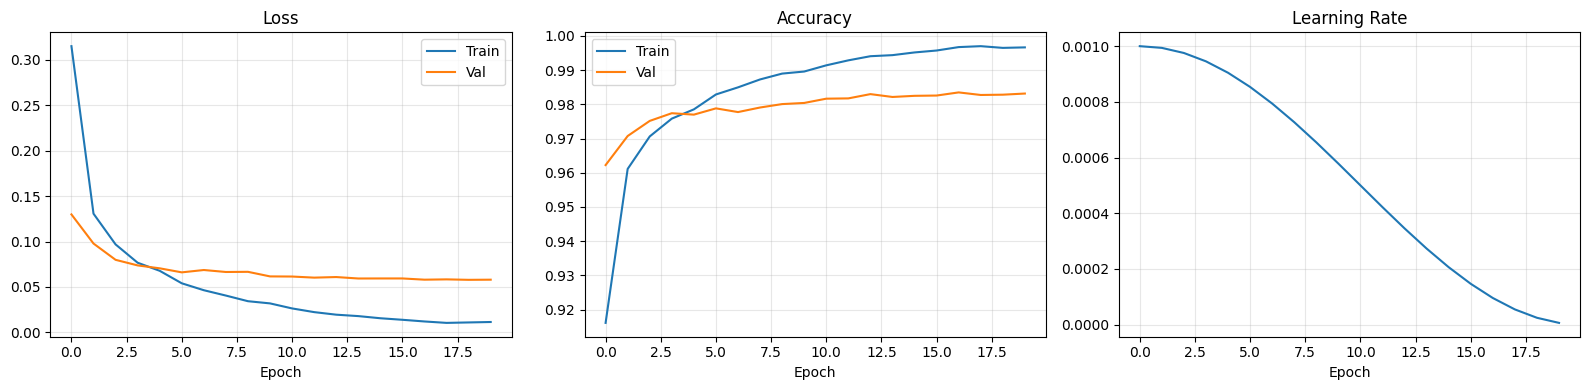

In [15]:
# Plot everything
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(history["lr"])
    axes[2].set_title("Learning Rate"); axes[2].set_xlabel("Epoch")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

### Final Test Evaluation

Evaluate the best model (loaded from checkpoint) on the test set:

In [16]:
# Final test evaluation
test_loss, test_acc = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
print(f"🎯 Test Accuracy: {test_acc:.2%}")
print(f"   Test Loss:     {test_loss:.4f}")

🎯 Test Accuracy: 98.48%
   Test Loss:     0.0575


---
## 7. Loading a Saved Model

In [17]:
# Demonstrate loading from checkpoint
new_model = MLP().to(device)
new_optimizer = optim.Adam(new_model.parameters())

epoch, val_loss = load_checkpoint(new_model, new_optimizer, "./checkpoints/best_model.pt", device)
print(f"Loaded checkpoint from epoch {epoch+1}, val_loss={val_loss:.4f}")

# Verify it works
test_loss, test_acc = evaluate(new_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"Test accuracy of loaded model: {test_acc:.2%}")

Loaded checkpoint from epoch 19, val_loss=0.0579
Test accuracy of loaded model: 98.48%


---
## 🧪 Exercises

### Exercise 1: Experiment tracker
Modify the `train()` function to save the history dict as a JSON file alongside the checkpoint. Write a function to load and compare multiple experiments.

### Exercise 2: Save only model weights
Sometimes you just need `model.state_dict()`. Save it with `torch.save(model.state_dict(), path)` and load it back with `model.load_state_dict(torch.load(path))`.

### Exercise 3: Resume training
Train for 5 epochs, save checkpoint, create a new model, load the checkpoint, and continue training for 5 more epochs.

### Exercise 4: Configuration dict
Create a config dict (batch_size, lr, hidden_dims, etc.) and use it everywhere. Save it with the checkpoint so you always know the hyperparameters.

In [ ]:
# Exercise 1: Your code here

In [ ]:
# Exercise 2: Your code here

In [ ]:
# Exercise 3: Your code here

In [ ]:
# Exercise 4: Your code here

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| **set_seed()** | Fix all random seeds for reproducibility |
| **Modular functions** | `train_one_epoch()`, `evaluate()` are reusable |
| **torch.save / torch.load** | Save/load model + optimizer state |
| **Best model checkpoint** | Always save the model with lowest validation loss |
| **Early stopping** | Stop when val loss hasn't improved for `patience` epochs |
| **History dict** | Track metrics for later analysis and plotting |

**Tomorrow:** We'll explore image data in depth — RGB channels, CIFAR-10, and data augmentation!